# 📌 Logistic Regression Cost Function

In this notebook, we will understand:

- Why Linear Regression cost function fails for classification
- What is Logistic Regression
- The Cost Function for Logistic Regression
- Why we use Log Loss (Cross Entropy)
- Visualization of cost behavior

This notebook is inspired by Andrew Ng's Machine Learning course.

## ❌ Why Linear Regression Cost Function Fails

Linear Regression uses Mean Squared Error:

\[
J(w, b) = \frac{1}{2m} \sum (y - \hat{y})^2
\]

Problems in classification:
- Outputs are not bounded between 0 and 1
- Leads to **non-convex cost function**
- Hard to optimize

👉 We need a better function for probabilities

## 🔁 Sigmoid Function

Logistic Regression uses the sigmoid function:

\[
\sigma(z) = \frac{1}{1 + e^{-z}}
\]

Where:
- \( z = wx + b \)
- Output is always between **0 and 1**

👉 This makes it perfect for classification problems

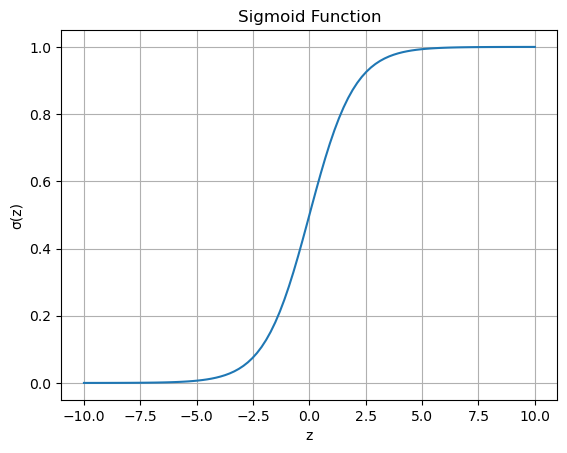

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)
y = sigmoid(z)

plt.figure()
plt.plot(z, y)
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("σ(z)")
plt.grid()
plt.show()

## 📉 Logistic Regression Cost Function

Instead of MSE, we use **Log Loss (Cross Entropy)**:

For one example:

If \( y = 1 \):
\[
\text{Cost} = -\log(\hat{y})
\]

If \( y = 0 \):
\[
\text{Cost} = -\log(1 - \hat{y})
\]

Combined:

\[
J(w, b) = -\frac{1}{m} \sum \left[ y \log(\hat{y}) + (1 - y)\log(1 - \hat{y}) \right]
\]

👉 This function is **convex**, so optimization is easier

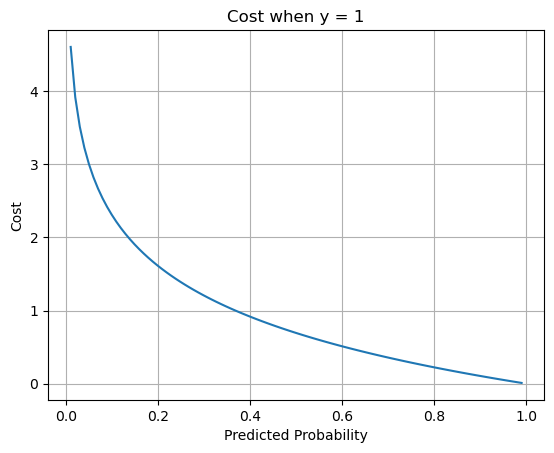

In [2]:
y_hat = np.linspace(0.01, 0.99, 100)

cost_y1 = -np.log(y_hat)

plt.figure()
plt.plot(y_hat, cost_y1)
plt.title("Cost when y = 1")
plt.xlabel("Predicted Probability")
plt.ylabel("Cost")
plt.grid()
plt.show()

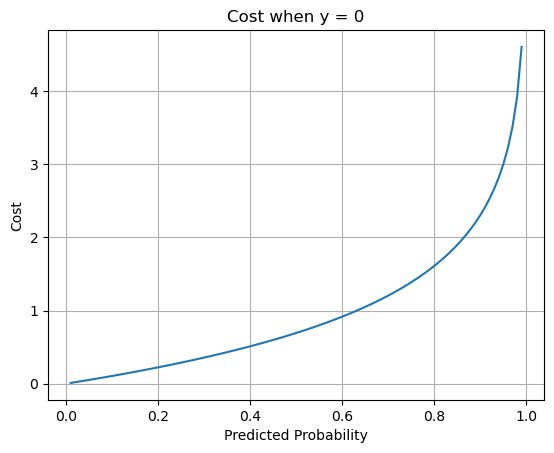

In [3]:
cost_y0 = -np.log(1 - y_hat)

plt.figure()
plt.plot(y_hat, cost_y0)
plt.title("Cost when y = 0")
plt.xlabel("Predicted Probability")
plt.ylabel("Cost")
plt.grid()
plt.show()

## 💡 Key Insight

- If prediction is **correct and confident** → low cost
- If prediction is **wrong and confident** → very high cost

Example:
- Predict 0.99 when y=1 → Good → Low loss
- Predict 0.01 when y=1 → Very bad → Huge loss

👉 This forces the model to learn correctly

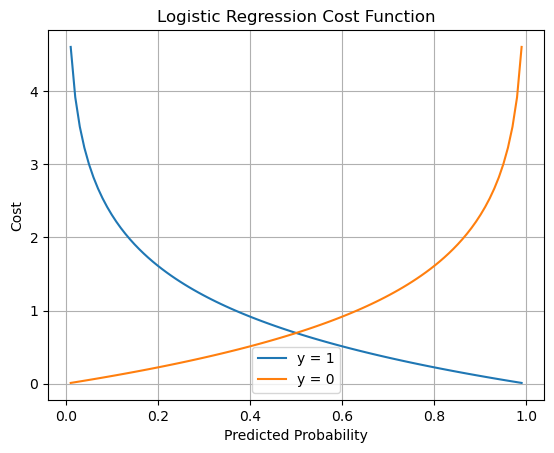

In [4]:
plt.figure()
plt.plot(y_hat, cost_y1, label="y = 1")
plt.plot(y_hat, cost_y0, label="y = 0")
plt.title("Logistic Regression Cost Function")
plt.xlabel("Predicted Probability")
plt.ylabel("Cost")
plt.legend()
plt.grid()
plt.show()

## 🎯 Real Meaning of Cost Function

This cost function measures:

👉 "How wrong is my probability prediction?"

It punishes:
- Overconfidence in wrong answers
- Rewards correct predictions

That’s why it works perfectly for classification

In [5]:
# Example

y_true = 1
y_pred = 0.9

cost = - (y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

print("Cost:", cost)

Cost: 0.10536051565782628


## 🧠 Interview Quick Notes

- Logistic Regression uses **Sigmoid**
- Output is probability (0 to 1)
- Cost Function = **Log Loss / Cross Entropy**
- Convex → easier optimization
- Penalizes wrong confident predictions heavily

👉 Always mention "convex optimization" in interviews